In [84]:
import nest_asyncio
nest_asyncio.apply()  # Required for Gremlin driver in Jupyter (avoids "event loop already running" error)

from pathlib import Path
from dotenv import load_dotenv

# Load .env from agents folder
env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'backend' / 'agents' / '.env'
if env_path.exists():
    load_dotenv(dotenv_path=env_path)
    print(f"✓ Loaded .env from: {env_path}")
else:
    print("⚠ .env not found in agents folder")

✓ Loaded .env from: /Users/rob.bajra/Projects/voice-to-rag/backend/agents/.env


In [85]:
from puppygraph import PuppyGraphClient, PuppyGraphHostConfig
client = PuppyGraphClient(PuppyGraphHostConfig("localhost"))
client.gremlin_query("g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()")


[path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[22cf81a4-ec3b-3c40-85b3-e8095d3e4417]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e8683443-4966-3966-83a2-2e075e9e8af4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e81b35a3-cf72-35e9-97cf-a4be96900eca]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[b49e3ee3-f53d-329b-960c-8baaedfaf5e4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],
 path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[95784050-52b8-3f5b-87c6-709556a6eb07]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]],


In [112]:

# Databricks model setup (E2 demo workspace)
from openai import OpenAI

ai_client = OpenAI(
  api_key=os.getenv("DATABRICKS_TOKEN"), # your personal access token
  base_url=os.getenv("DATABRICKS_HOST") + "serving-endpoints", # your Databricks workspace instance
)


In [135]:
# PuppyGraph tools (reload to pick up changes)
import importlib
import gremlin_tool
import graph_viz_tool
importlib.reload(gremlin_tool)
importlib.reload(graph_viz_tool)

from gremlin_tool import (
    GENERATE_GREMLIN_TOOL_SPEC, generate_gremlin,
    EXECUTE_GREMLIN_TOOL_SPEC, execute_gremlin,
)
from graph_viz_tool import (
    VISUALIZE_LINEAGE_TOOL_SPEC, visualize_lineage,
)

# Tool specs (dicts for the OpenAI API) and local functions
TOOLS = [GENERATE_GREMLIN_TOOL_SPEC, EXECUTE_GREMLIN_TOOL_SPEC, VISUALIZE_LINEAGE_TOOL_SPEC]



In [139]:
import json

def AGENT(user_query: str):
    # Map tool names to their local Python functions
    TOOL_FUNCTIONS = {
        "generate_gremlin": generate_gremlin,
        "execute_gremlin": execute_gremlin,
        "visualize_lineage": visualize_lineage,
    }

    LLM_ENDPOINT_NAME = "databricks-claude-sonnet-4-5"
    MAX_TOOL_ROUNDS = 5  # safety limit to avoid infinite loops

    messages = [
        {
            "role": "system",
            "content": """
            You are a PuppyGraph agent.
            Before each action, explain your reasoning step by step.
            Use the generate_gremlin tool to convert natural language questions into Gremlin queries.
            Then use the execute_gremlin tool to run the query and return results.
            Always call execute_gremlin after generate_gremlin to get the actual data.
            When the user asks about lineage, data flow, or graph relationships,
            also call visualize_lineage with the same Gremlin query to render an
            inline graph visualization.
            """,
        },
        {
            "role": "user",
            "content": user_query,
        },
    ]

    # Agentic loop: keep calling the LLM until it stops requesting tool calls
    for round_num in range(MAX_TOOL_ROUNDS):
        response = ai_client.chat.completions.create(
            messages=messages,
            model=LLM_ENDPOINT_NAME,
            tools=TOOLS,
            max_tokens=1024,
        )

        choice = response.choices[0]

        if choice.finish_reason != "tool_calls":
            # Model is done — print final answer
            print("Final answer:", choice.message.content)
            break

        # Process tool calls
        messages.append(choice.message)

        for tool_call in choice.message.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)
            print(f"[Round {round_num + 1}] Tool call: {fn_name}({fn_args})")

            result = TOOL_FUNCTIONS[fn_name](**fn_args)
            print(f"[Round {round_num + 1}] Tool result: {result}\n")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })
    else:
        print("⚠ Reached max tool rounds without a final answer")


## Lineage Q&A with agent

In [140]:
AGENT("List 10 tables")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').id().limit(10)"})
[Round 1] Tool result: g.V().hasLabel('table').id().limit(10)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').id().limit(10)"})
[Round 1] Tool result: ["table[00vsdb.agent_analytics.agents_clean]", "table[00vsdb.default.student_silver]", "table[00vsdb.mlops.openai_payload]", "table[03_31_2025_test_cs.dbdemos_aibi_customer_support.agents_bronze]", "table[03_34_2025_test_cs.dbdemos_aibi_cme_marketing_campaign.feedbacks]", "table[04_01_cal_test_aibi_customer_support.dbdemos_aibi_customer_support.agents_bronze]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.__materialization_mat_624bbb00_aa4d_499b_b4d9_e0313e828d3d_claim_policy_telematics_1]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.claim_policy_telematics]", "table[04_29_2025_test_cal_claims.dbdemos_fsi_smart_claims.damage_predictions]", "table[04_29_2025_test_cal_claims.dbdem

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.agents_clean]').bothE('lineage').path()"})
[Round 1] Tool result: ["path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[22cf81a4-ec3b-3c40-85b3-e8095d3e4417]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e8683443-4966-3966-83a2-2e075e9e8af4]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[table[00vsdb.agent_analytics.agents_clean]], e[lineage[e81b35a3-cf72-35e9-97cf-a4be96900eca]][table[00vsdb.agent_analytics.agents_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]]]", "path[v[

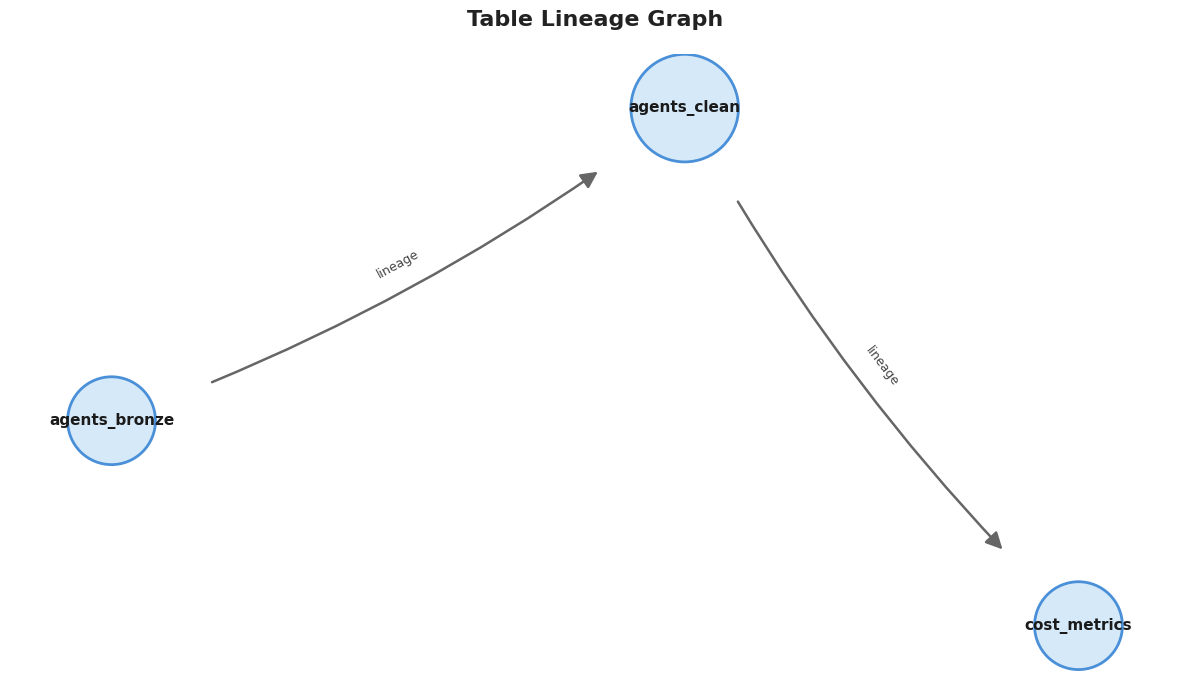

[Round 1] Tool result: Lineage graph rendered: 3 nodes (agents_clean, cost_metrics, agents_bronze), 2 edges.

Final answer: Perfect! I've retrieved and visualized the lineage for `00vsdb.agent_analytics.agents_clean`. Here's what I found:

## Lineage Summary

The table `agents_clean` has:

**Upstream (Source):**
- `00vsdb.agent_analytics.agents_bronze` → feeds data into `agents_clean`

**Downstream (Target):**
- `agents_clean` → feeds data into `00vsdb.agent_analytics.cost_metrics` (through 6 different lineage records)

The visualization above shows the complete lineage graph with:
- **3 nodes**: agents_bronze, agents_clean, and cost_metrics
- **2 edges**: representing the data flow relationships

This indicates that `agents_clean` is a transformation/cleaning layer that takes data from the bronze layer (`agents_bronze`) and produces cleaned data that is then used by the `cost_metrics` table for analysis.


In [141]:
AGENT("show lineage of 00vsdb.agent_analytics.agents_clean")

In [142]:
AGENT("How many unique tables are upsteam of 00vsdb.agent_analytics.cost_metrics")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().dedup().count()"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().dedup().count()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().dedup().count()"})
[Round 1] Tool result: [3]

Final answer: There are **3 unique tables** upstream of `00vsdb.agent_analytics.cost_metrics`.

This means that the `cost_metrics` table directly depends on 3 other tables as its data sources.

Would you like me to show you which specific tables are upstream, or visualize the lineage graph?


[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path()"})
[Round 1] Tool result: g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path()

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[00vsdb.agent_analytics.cost_metrics]').inE('lineage').outV().path()"})
[Round 1] Tool result: ["path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[abfc459f-a928-3e69-9fa7-e94ec4077c91]][table[00vsdb.agent_analytics.sla_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]], v[table[00vsdb.agent_analytics.sla_clean]]]", "path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[264f2529-df28-3d25-863e-268d08dd86c1]][table[00vsdb.agent_analytics.sla_clean]-lineage->table[00vsdb.agent_analytics.cost_metrics]], v[table[00vsdb.agent_analytics.sla_clean]]]", "path[v[table[00vsdb.agent_analytics.cost_metrics]], e[lineage[e8d0bd10-7a83-309e-b339-86b4e8d6252f]][table[00vs

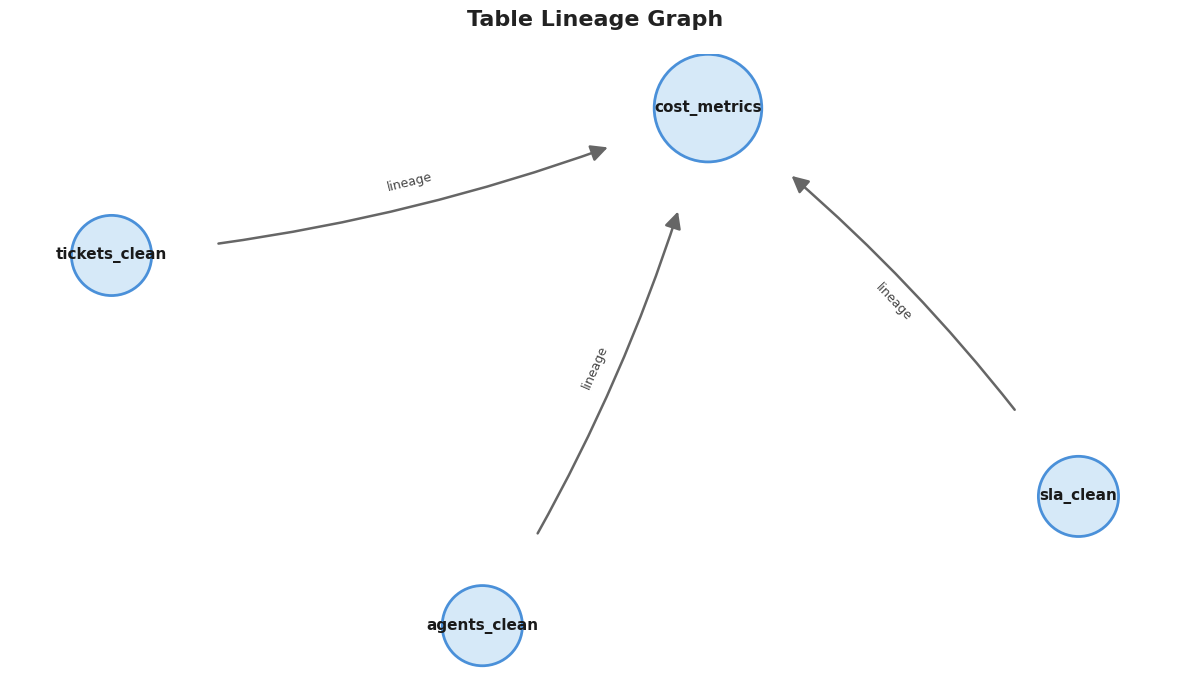

[Round 1] Tool result: Lineage graph rendered: 4 nodes (cost_metrics, sla_clean, agents_clean, tickets_clean), 3 edges.

Final answer: Perfect! I've found the upstream lineage for `00vsdb.agent_analytics.cost_metrics`. 

## Results:

The table **cost_metrics** has **3 upstream source tables**:

1. **00vsdb.agent_analytics.sla_clean** - 6 lineage relationships
2. **00vsdb.agent_analytics.tickets_clean** - 6 lineage relationships  
3. **00vsdb.agent_analytics.agents_clean** - 6 lineage relationships

The visualization above shows the data flow, where all three tables (sla_clean, tickets_clean, and agents_clean) feed data into the cost_metrics table. This indicates that cost_metrics is likely a derived or aggregated table that combines data from these three upstream sources to calculate cost-related metrics.


In [143]:
AGENT("Show upstream lineage of 00vsdb.agent_analytics.cost_metrics")

In [144]:
AGENT("What is the most connected table")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).order().by(select('deg'), desc).limit(1)"})
[Round 1] Tool result: [{"deg": 4324100, "id": "table[system.__internal_logging.payload_logs]"}]

Final answer: The most connected table is **`system.__internal_logging.payload_logs`** with **4,324,100 lineage connections** (both upstream and downstream combined).

This table appears to be a system logging table that likely captures payload information from many different sources and processes, which explains why it has such a high number of connections in the lineage graph.


In [145]:
AGENT("What are the top 5 tables with the most downstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'downstream_count').by(id()).by(outE('lineage').count()).order().by(select('downstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"downstream_count": 4324100, "id": "table[system.__internal_logging.payload_logs]"}, {"downstream_count": 2172314, "id": "table[macq_energy_data.silver.parsed_events]"}, {"downstream_count": 367221, "id": "table[macq_energy_data.bronze.events]"}, {"downstream_count": 367221, "id": "table[macq_energy_data.bronze.events]"}, {"downstream_count": 363400, "id": "table[system.billing.usag

In [146]:
AGENT("What are the top 5 tables with the most upstream lineage")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'upstream_count').by(id()).by(inE('lineage').count()).order().by(select('upstream_count'), desc).limit(5)"})
[Round 1] Tool result: [{"id": "table[macq_energy_data.silver.news_events]", "upstream_count": 409986}, {"id": "table[macq_energy_data.silver.news_events]", "upstream_count": 409986}, {"id": "table[macq_energy_data.silver.facility_utilization]", "upstream_count": 390930}, {"id": "table[macq_energy_data.silver.facility_utilization]", "upstream_count": 390930}, {"id": "table[macq_energy_data.silver.market_data]", "upstream_

In [147]:
AGENT("Show 5 tables in puppygraph that have 5 dependencies ")

[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 1] Tool result: g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V().hasLabel('table').project('id', 'deg').by(id()).by(bothE('lineage').count()).where(select('deg').is(5)).limit(5)"})
[Round 1] Tool result: [{"deg": 5, "id": "table[demo_generator.juan_calero_hc_demo_jc.gold_cat_event_impact]"}, {"deg": 5, "id": "table[demo_generator.juan_calero_jc_comp_x.silver_patient_cohort]"}, {"deg": 5, "id": "table[demo_generator.juan_calero_lakebase_demo_app.gold_data_quality_monitoring]"}, {"deg": 5, "id": "table[demo_generator.juan_carballo_chile_retail.gold_store_sku_inventory_daily]"}, {"deg": 5, "id": "table[demo_generator.julia_wu_opala_data_demo.gold_synth_quality_timeseries]"}]


[Round 1] Tool call: generate_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').bothE('lineage').otherV().path().limit(100)"})
[Round 1] Tool result: g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').bothE('lineage').otherV().path().limit(100)

[Round 1] Tool call: execute_gremlin({'gremlin_query': "g.V('table[mcutini_tuva.core._stg_claims_medical_claim]').bothE('lineage').otherV().path().limit(100)"})
[Round 1] Tool result: ["path[v[table[mcutini_tuva.core._stg_claims_medical_claim]], e[lineage[2f92bf43-1064-3dad-a785-15a38b6609ec]][table[mcutini_tuva.core._stg_claims_medical_claim]-lineage->table[mcutini_tuva.core.medical_claim]], v[table[mcutini_tuva.core.medical_claim]]]", "path[v[table[mcutini_tuva.core._stg_claims_medical_claim]], e[lineage[815bf3a1-ac29-31d3-bfb0-7f200b2bedef]][table[mcutini_tuva.core._stg_claims_medical_claim]-lineage->table[mcutini_tuva.core._stg_claims_practitioner]], v[table[mcutini_tuva.core._stg_claims_practitione

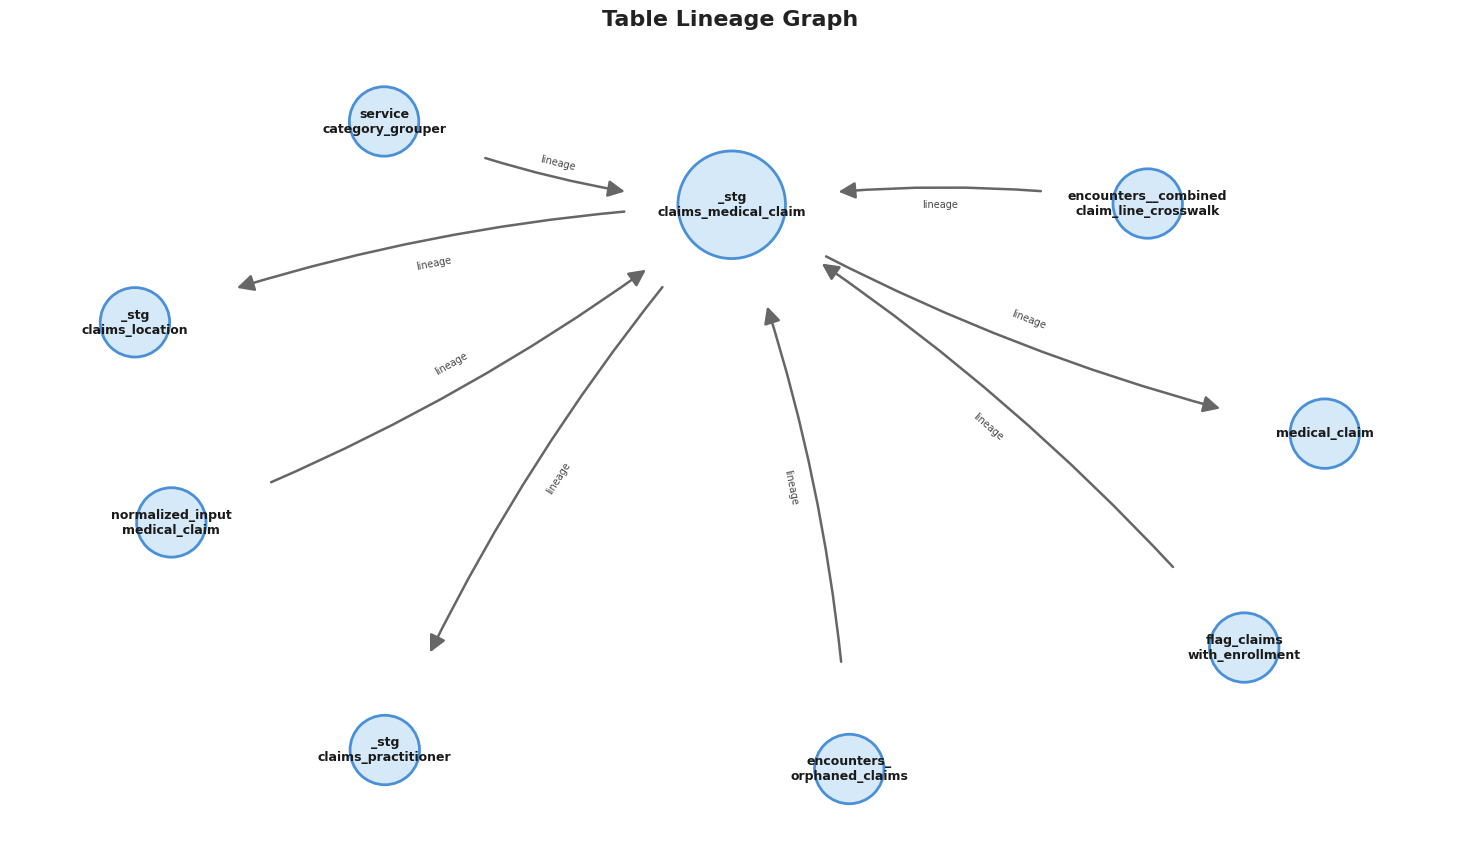

[Round 1] Tool result: Lineage graph rendered: 9 nodes (_stg_claims_medical_claim, medical_claim, _stg_claims_practitioner, _stg_claims_location, encounters__combined_claim_line_crosswalk, service_category_grouper, flag_claims_with_enrollment, encounters__orphaned_claims, normalized_input_medical_claim), 8 edges.

Final answer: Perfect! I've successfully retrieved and visualized the lineage for `mcutini_tuva.core._stg_claims_medical_claim`. 

## Summary

The table **`mcutini_tuva.core._stg_claims_medical_claim`** has **8 lineage connections**:

### **Upstream Sources (4 tables feeding into it):**
1. `mcutini_tuva.claims_preprocessing.normalized_input_medical_claim`
2. `mcutini_tuva.claims_preprocessing.encounters__combined_claim_line_crosswalk`
3. `mcutini_tuva.claims_preprocessing.flag_claims_with_enrollment`
4. `mcutini_tuva.claims_preprocessing.service_category_grouper`
5. `mcutini_tuva.claims_preprocessing.encounters__orphaned_claims`

### **Downstream Targets (3 tables it feeds in

In [148]:
AGENT("Show lineage of mcutini_tuva.core._stg_claims_medical_claim")